... saving models ...
episode 0 score 26.0 avg score 26.0 time_steps 26 learning_steps 1
episode 1 score 25.0 avg score 25.5 time_steps 51 learning_steps 2
episode 2 score 10.0 avg score 20.3 time_steps 61 learning_steps 3
episode 3 score 15.0 avg score 19.0 time_steps 76 learning_steps 3
episode 4 score 9.0 avg score 17.0 time_steps 85 learning_steps 4
episode 5 score 14.0 avg score 16.5 time_steps 99 learning_steps 4
episode 6 score 22.0 avg score 17.3 time_steps 121 learning_steps 6
episode 7 score 13.0 avg score 16.8 time_steps 134 learning_steps 6
episode 8 score 21.0 avg score 17.2 time_steps 155 learning_steps 7
episode 9 score 34.0 avg score 18.9 time_steps 189 learning_steps 9
episode 10 score 21.0 avg score 19.1 time_steps 210 learning_steps 10
episode 11 score 71.0 avg score 23.4 time_steps 281 learning_steps 14
episode 12 score 23.0 avg score 23.4 time_steps 304 learning_steps 15
episode 13 score 39.0 avg score 24.5 time_steps 343 learning_steps 17
episode 14 score 19.0 avg

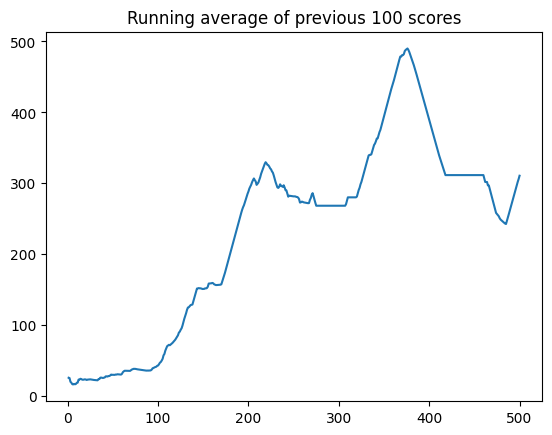

In [8]:
import gym
import numpy as np
from ppo import Agent
from utils import plot_learning_curve

if __name__ == '__main__':
    env = gym.make('CartPole-v1')
    N = 20
    batch_size = 5
    n_epochs = 4
    alpha = 0.0003 # More stable than 0.0003
    agent = Agent(n_actions=env.action_space.n, batch_size=batch_size, 
                    alpha=alpha, n_epochs=n_epochs, 
                    input_dims=env.observation_space.shape)
    n_games = 500

    figure_file = 'plots/cartpole.png'

    best_score = env.reward_range[0]
    score_history = []

    learn_iters = 0
    avg_score = 0
    n_steps = 0

    for i in range(n_games):
        reset_result = env.reset()
        observation = reset_result[0] if isinstance(reset_result, tuple) else reset_result # Handle different gym versions
        
        terminated = False
        truncated = False
        score = 0
        while not (terminated or truncated):
            action, prob, val = agent.choose_action(observation)
            observation_, reward, terminated, truncated, info = env.step(action)
            n_steps += 1
            score += reward
            
            # Add these debug lines:
            done = terminated or truncated
            agent.remember(observation, action, prob, val, reward, done)
            if n_steps % N == 0:
                agent.learn()
                learn_iters += 1
            observation = observation_
        score_history.append(score)
        avg_score = np.mean(score_history[-100:])

        if avg_score > best_score:
            best_score = avg_score
            agent.save_models()

        print('episode', i, 'score %.1f' % score, 'avg score %.1f' % avg_score,
                'time_steps', n_steps, 'learning_steps', learn_iters)
    x = [i+1 for i in range(len(score_history))]
    plot_learning_curve(x, score_history, figure_file)



In [5]:
print(f"Environment: {env.spec.id}")
print(f"Max episode steps: {env._max_episode_steps}")
print(f"Reward range: {env.reward_range}")
print(f"Gym version: {gym.__version__}")

Environment: CartPole-v1
Max episode steps: 500
Reward range: (-inf, inf)
Gym version: 0.26.2
